In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\Users\\Sachidanand\\Project\\Sample - Superstore cleaned.csv', encoding='latin-1')
print("Shape:", df.shape)
print(df.head())

Shape: (9994, 23)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  08-11-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  08-11-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  12-06-2016  16-06-2016    Second Class    DV-13045   
3       4  US-2015-108966  11-10-2015  18-10-2015  Standard Class    SO-20335   
4       5  US-2015-108966  11-10-2015  18-10-2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

        Product ID         Category Sub-Category  \
0  FUR-BO-10001798    

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
dtype: int64


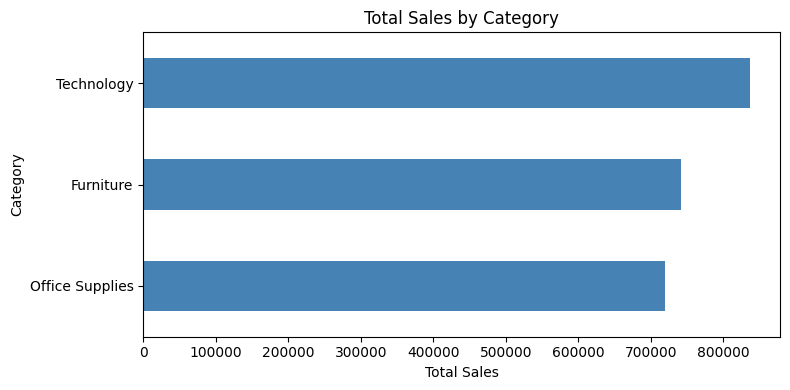

In [ ]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
cat_sales.plot(kind='barh', title='Total Sales by Category', color='steelblue', figsize=(8,4))
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

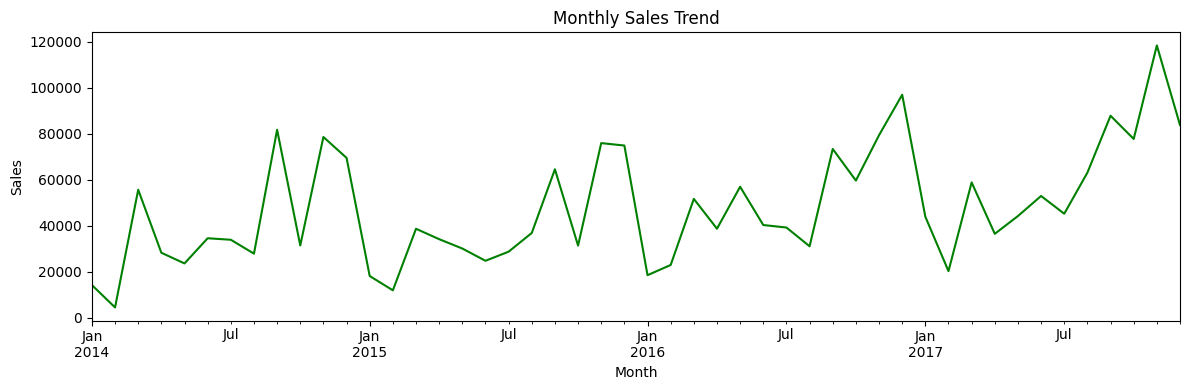

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()
monthly.plot(title='Monthly Sales Trend', figsize=(12,4), color='green')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

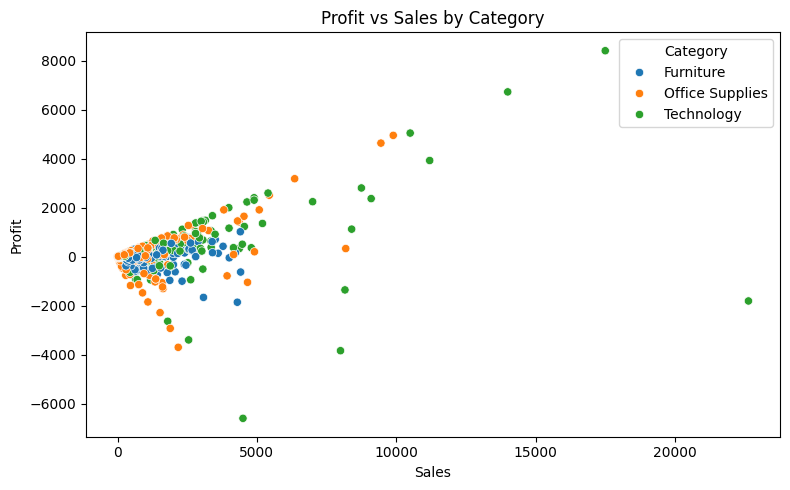

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title('Profit vs Sales by Category')
plt.tight_layout()
plt.show()

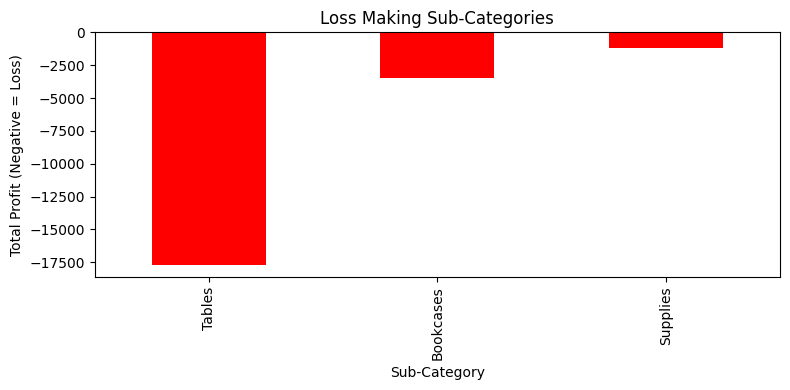

In [6]:
losses = df.groupby('Sub-Category')['Profit'].sum().sort_values()
losses[losses < 0].plot(kind='bar', title='Loss Making Sub-Categories', color='red', figsize=(8,4))
plt.ylabel('Total Profit (Negative = Loss)')
plt.tight_layout()
plt.show()